## EBM fit

install https://github.com/kurmukovai/ebm-progression by cloning the repo and `pip install -e .`

In [106]:
from ebm.probability import log_distributions, fit_distributions, predict_stage
from ebm.mcmc import greedy_ascent, mcmc, get_optimal_order
from ebm.likelihood import EventProbabilities

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [84]:


X_val = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_val_68biom.npy", allow_pickle = True)
X_train = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_train_68biom.npy", allow_pickle= True)
K = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/K_68.npy")

biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']


def unpack_patient_list(patient_list):
    X_obs = []
    dt = []
    ids = []
    cog = []
    nhy = []
    for patient in patient_list:
        n_visits = patient["dt"].shape[0]
        pid = patient["id"]
        X_obs.append(patient["X_obs"])
        dt.append(patient["dt"])
        ids.append(np.full(n_visits, pid))
        cog.append(patient["cog"])
        nhy.append(patient["nhy"])
    return (
        np.vstack(X_obs),
        np.concatenate(dt),
        np.concatenate(ids),
        np.vstack(cog),
        np.concatenate(nhy),
    )

    
X_train_obs, X_train_dt, X_train_ids, X_train_cog, X_train_nhy = unpack_patient_list(X_train)
X_val_obs, X_val_dt, X_val_ids, X_val_cog, X_val_nhy = unpack_patient_list(X_val)

y_val = np.ones(X_val_obs.shape[0])
y_train = np.ones(X_train_obs.shape[0])

df_td = pd.read_csv("/data01/bgutman/MRI_data/PPMI/PPMI_regional_TD.csv")
df_pg = pd.read_csv("/data01/bgutman/MRI_data/PPMI/PPMI_regional_PIGD.csv")

y_td = df_td["Dx"].to_numpy()
y_pg = df_pg["Dx"].to_numpy()

#print(df_td.head(1))

df_td = df_td[biomarker_names].copy()
X_td = df_td[[col for col in df_td.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_td = X_td.to_numpy()
X_td = np.max(X_td, axis=0) - X_td

df_pg = df_pg[biomarker_names].copy()
X_pg = df_pg[[col for col in df_pg.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_pg = X_pg.to_numpy()
X_pg = np.max(X_td, axis=0) - X_pg



# biomarker_names_2 = [col for col in df_td.columns 
#                    if col.startswith(('L_', 'R_')) and 
#                    col.endswith('_thickavg') and 
#                    not col.endswith('_thickavg_resid')]
#print(Xtd.head)

X_val = X_val_obs
y_val = y_val

X_full = np.vstack([X_td, X_pg, X_train_obs])
y_full = np.concatenate([y_td, y_pg, y_train])

log_p_e, log_p_not_e = log_distributions(X=X_full, y=y_full, point_proba=False)

starting_order = np.arange(0,68, dtype=int)
rng = np.random.RandomState(75)
rng.shuffle(starting_order)
print(starting_order)

[31 65 61  2 13 18 11 27 41 29  3 21 49  4 22 44 40  5 53 59 12 58  9 39
 62 60 66 23 33 24 50 15  1 46 57 54 37 56 35 52 14 67 10 28 47 20 16  0
 30 48 36 42 38 45 25 43 51 63 55  7 32 17 34  6 26 64  8 19]


In [85]:
order, loglike, update_iters = greedy_ascent(log_p_e, log_p_not_e, 
                                             n_iter=10_000, order = starting_order,
                                             random_state=2020, prior=None)

100%|██████████| 10000/10000 [00:14<00:00, 693.18it/s]


In [86]:
# almost correct, good job
order

array([41,  4, 45, 67, 12, 39, 46, 55, 33, 11, 43, 42, 47,  8, 44, 50, 57,
       40,  5, 62,  7, 13,  9,  6, 10, 29, 28,  3, 27, 37,  2, 20, 19, 53,
       49, 22, 15, 56, 54, 32, 61, 36, 23, 16, 63, 25, 26, 59, 58, 17, 60,
       52, 18, 51, 21, 24,  1, 30, 64,  0, 34, 31, 65, 38, 48, 14, 66, 35])

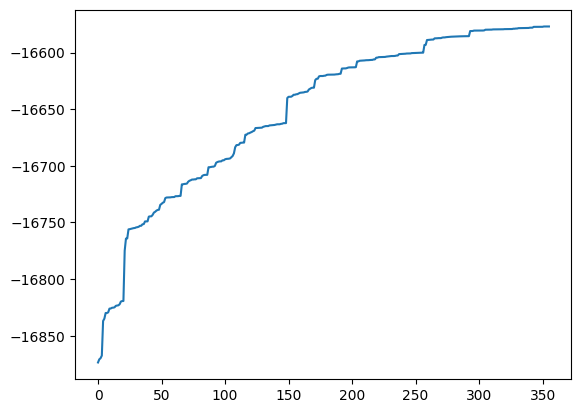

In [87]:
plt.plot(loglike)

In [88]:
orders, loglike, update_iters, probas = mcmc(log_p_e, log_p_not_e,
                                                 order=order, n_iter=500_000,
                                                 random_state=2020)

100%|██████████| 500000/500000 [12:05<00:00, 689.64it/s]


In [103]:
orders[:][1]

array([41,  4, 44, 67, 12, 39, 46, 55, 33, 11, 43, 42, 47,  8, 45, 50, 57,
       40,  5, 62,  7, 13,  9,  6, 10, 29, 28,  3, 27, 37,  2, 20, 19, 53,
       49, 22, 15, 56, 54, 32, 61, 36, 23, 16, 63, 52, 26, 59, 58, 17, 60,
       25, 18, 51, 21, 24,  1, 30, 64,  0, 34, 31, 65, 38, 48, 14, 66, 35])

In [104]:
# orders[1,1]
len(orders[0])

68

In [108]:
def get_optimal_order2(orders: list):
    """Computes optimal order from list of orders obtained over MCMC runs."""
    # TODO: number of regions is hardcoded
    # How many time region `r` is on position `i`
    n_stages = len(orders[0])
    order_map = np.zeros((n_stages,n_stages))
    for i in range(n_stages):
        region, freq = np.unique(orders[:][i], return_counts=True)
        # region, freq = np.unique(orders[:, i], return_counts=True)
        for r, f in zip(region, freq):
            order_map[r, i] = f
            
    # Optimal order
    best_order = []
    for i in range(n_stages):
        candidate_regions = np.argsort(order_map[:, i])[::-1]
        for reg in candidate_regions:
            if reg not in best_order:
                best_order.append(reg)
                break
    best_order = np.array(best_order)  
    return order_map, best_order

In [109]:
order_map, best_order = get_optimal_order2(orders)

In [110]:
best_order

array([67, 24, 18, 19, 20, 21, 22, 23, 25, 66, 26, 27, 28, 29, 30, 31, 17,
       16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1, 32,
       33, 34, 51, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52,
       50, 35, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36,  0])

In [89]:
#orders[:10]
print(len(orders))
if orders == []:
    best_order = order
else:
    best_order = orders[np.argmax(loglike)]
    
print(np.array(best_order))

201786
[41  4 44 67 12 39 46 55 33 11 43 42 47  8 45 50 57 40  5 62  7 13  9  6
 10 29 28  3 27 37  2 20 19 53 49 22 15 56 54 32 61 36 23 16 63 25 26 59
 58 17 60 52 18 51 21 24  1 30 64  0 34 31 65 38 48 14 66 35]


In [116]:
y_test

array([1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1.,
       0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.,
       1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1.,
       1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 1.])

In [117]:
sum(y_train)/len(y_train)

1.0

In [ ]:
sum(y_test)/len(y_test)

0.7361963190184049

In [112]:
test_log_p_e

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [ ]:
#best_order = [41,39,62,32,47,56,34,13,63,2,36,26,7,29,22,60,40,23,57,6,48,61,27,9,5,49,28,15,18,67,20,1,0,66,19,37,25,10,59,64,54,51,44,31,53,45,43,52,11,4,35,38,30,16,8,50,33,58,46,42,14,65,21,55,3,12,24,17]

test_log_p_e, test_log_p_not_e = log_distributions(X=X_full, y=y_full, point_proba=False, X_test=X_val_obs,y_test=y_val)
# test_log_p_e, test_log_p_not_e = log_distributions(X=X_train_obs, y=y_train, point_proba=False, X_test=X_val_obs,y_test=y_val)
# test_log_p_e, test_log_p_not_e = log_distributions(X=X_val_obs, y=y_val, point_proba=False)


from ebm.probability import predict_stage

# probas = predict_stage(best_order, train_log_p_e, train_log_p_not_e).T
# train_stage = np.argmax(probas, axis=1)

probas = predict_stage(best_order, test_log_p_e, test_log_p_not_e).T
test_stage = np.argmax(probas, axis=1)



/home/dsemchin/Progression_models_simulations/ebm/probability.py:15: RuntimeWarning: Mean of empty slice.
  avg = X[y==0, ...].mean(axis=0)
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [91]:
np.shape(np.argmax(probas,axis=1))

(103,)

<Axes: ylabel='Count'>

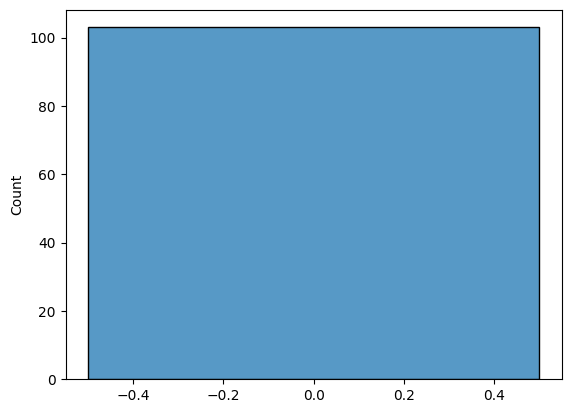

In [92]:
import seaborn as sns

sns.histplot(np.argmax(probas,axis=1))

In [93]:

print(len(test_stage), len(X_val_nhy))

from scipy.stats import spearmanr, kendalltau

print(spearmanr(X_train_nhy, train_stage))


print(train_stage)

print(np.sum(np.isnan(X_val_nhy)))
print(np.sum(np.isnan(test_stage)))

103 103
SignificanceResult(statistic=nan, pvalue=nan)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0
0


/tmp/ipykernel_10990/907213950.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  print(spearmanr(X_train_nhy, train_stage))


In [125]:
orders = np.load("/data01/bgutman/parkinson_ebm/results/mc_mc_results/parkinson/cdf_proba/aver_prior/order_mcmc.npz", allow_pickle=True)


FileNotFoundError: [Errno 2] No such file or directory: '/data01/bgutman/parkinson_ebm/results/mc_mc_results/parkinson/cdf_proba/aver_prior/order_mcmc.npz'